In [68]:
from copy import deepcopy
from itertools import groupby 
import numpy as np 
import matplotlib.pyplot as plt
import neuralnet as nn 
from neuralnet.preprocess import prepare_data, hot_encode
from neuralnet.activations import step, derivative_htanh , relu, derivative_relu
from neuralnet.losses import l2_hinge_loss_gradient
from neuralnet.spin_glass_utils import form_J_matrix, form_bond_matrix
from joblib import Parallel, delayed

layer_sizes = [784,512,512,512,10]
βs = np.arange(0,1.4,.1)

def map_nn_to_spin_glass(x: np.ndarray[:], spin_net: nn.NeuralNetwork) -> list[np.ndarray]:
    """
    Map a neural network to an Ising-model spin-glass with external magnetic field.

    Args:
        x (array): Input data point.
        spin_net (object): Neural network with weights and biases.

    Returns:
        list: Spin configurations at each layer of the network.
    """
    # Initialize spin configurations
    spins = [np.where(step(x) > .5, 1, -1)]  # Input layer spins
    
    # Iterate over the layers of the network
    activation = spins[0]
    for l in range(spin_net.layer_n - 1):
        # Compute activation and determine spins for the current layer
        activation = step(spin_net.weights[l] @ activation + spin_net.bias[l])
        spins.append(np.where(activation > 0, 1, -1))
    
    return spins
  
def calculate_hamiltonian(J: list[np.ndarray[:,:]], S: list[np.ndarray[:]]) -> (int | float):

    """
    Calculates the hamiltonian for a multi-layer spin-glass model

    Parameters:
    ----------
    J : list
        A list of learning rates (η) to test. Default is [1e-4, 1e-2, 1e-1].
    S : list
        A list of momentum values (γ) to test, including None for no momentum.
        Default is [None, 1e-2, 1e-1].
    Returns:
    -------
    list[tuple]
        A list of tuples representing the results for each hyperparameter combination.
        Each tuple contains:
            - Activation function name (str).
            - Learning rate (η).
            - Momentum value (γ).
            - Pool size.
            - A list of validation accuracy percentages over the runs.

    Example:
    --------
    result = search_hyperparameters(
        learning_rates=[0.001, 0.01],
        momentums=[0.9, None],
        pools=[32],
        runs=50,
        epoch_unit=5
    )
    """
    
    n = len(J)
    H = 0.0
    for l in range(0, n):
        si , sj = S[l],  S[l+1]
        W = J[l]
        H -= np.sum((W @ si) * sj)

    return H 

def calculate_heat_capacity(J,S,β):

     # Total number of spins
    N = sum(len(s) for s in S)
    
    # Compute energy 
    Si = calculate_hamiltonian(J,S)
    
    # Compute pairwise spin product sum (SiSj)
    SiSj = 0.0
    for i in range(len(S) - 1):
        # Broadcast multiply only valid ranges between S[i] and S[i+1]
        SiSj += np.sum(S[i][:, None] * S[i + 1])
    
    # Calculate susceptibility
    χ = β * (SiSj / N - (Si / N)**2)
    
    return  χ

def calculate_magnetization(J, S: list[np.ndarray[:]],β) -> (float | int):
    """
    Calculates the magnetization sum(s)/N for a multi-layer spin-glass model

    """
    β
    N = sum(len(s) for s in S)
    M = sum(np.sum(s) for s in S)/N
    return M

def calculate_overlap(J,S,β):
    β
    N = sum(len(s) for s in S)
    M = sum(np.sum(s**2) for s in S)/N
    return M

def calculate_second_magnetization(J, S: list[np.ndarray[:]],β) -> (float | int):
    """
    Calculates the magnetization sum(s)/N for a multi-layer spin-glass model

    """
    N = sum(len(s) for s in S)
    M2 = (sum(np.sum(s) for s in S)/N)**2
    return M2

def calculate_fourth_magnetization(J, S: list[np.ndarray[:]],β) -> (float | int):
    """
    Calculates the magnetization sum(s)/N for a multi-layer spin-glass model

    """
    N = sum(len(s) for s in S)
    M = (sum(np.sum(s) for s in S)/N)**4
    return M

def calculate_susceptibility(J, S: list[np.ndarray[:]], β: (int | float)) -> (int | float):
    """

    
    
    """
    # Total number of spins
    N = sum(len(s) for s in S)
    
    # Compute total spin sum (Si)
    Si = sum(np.sum(s) for s in S)
    
    # Compute pairwise spin product sum (SiSj)
    SiSj = 0.0
    for i in range(len(S) - 1):
        # Broadcast multiply only valid ranges between S[i] and S[i+1]
        SiSj += np.sum(S[i][:, None] * S[i + 1])
    
    # Calculate susceptibility
    χ = β * (SiSj / N - (Si / N)**2)
    
    return  χ



def compute_before_after_hamiltonians(x,spin_net,spin_net_after):
    spin_glass_vector = map_nn_to_spin_glass(x, spin_net)
    spin_glass_vector_after = map_nn_to_spin_glass(x, spin_net_after)
    H = calculate_hamiltonian(spin_net.weights, spin_glass_vector)
    H_after = calculate_hamiltonian(spin_net_after.weights, spin_glass_vector_after)
    return H, H_after
    
def monte_carlo_on_spins(J: list[np.ndarray[:,:]], 
                         S: list[np.ndarray[:]],
                         thermodynamic_quantities: list[callable],  
                         β: (int | float),iterations: (int),
                         inplace=False) -> (list[np.ndarray[:],list[float]]):

    """
    Perform Ising Monte-Carlo on spins

    Parameters
    ----------
    J : list[np.ndarray[:,:]]
        list of 2d arrays representing bond matrices between layers of spins
    S : list[np.ndarray[:]]
        list of 1d arrays each one representing layer of spin
    thermodynamic_quantities: list[callable]
        pass a list of thermo functions with signature f(J,S,β)
    β : float 
        inverse temperature
    iterations : int, optional
        number of iterations for simulation

    Returns
    -------
    New final configuration S_ of spins and a list of thermodynamic quantities for all configurations
    """
    
    thermodynamic_info = []
    if inplace is True:
        S_ = S
    else:
        S_ = deepcopy(S)

    for _ in range(0,iterations):
        array_index = np.random.randint(0, len(S_) - 1)
        element_index = np.random.randint(0, len(S[array_index]) - 1)
        E0 = calculate_hamiltonian(J,S_)
        # flip the spin 
        S_[array_index][element_index]= -1.0 * S_[array_index][element_index]
        E = calculate_hamiltonian(J,S_)
        ΔE = E-E0 
        if ΔE < 0 : 
            pass 
        else: 
            p_keep = np.exp(-β*ΔE)
            accept_reject = np.random.choice([1.0,-1.0],p=[p_keep,1-p_keep ])
            S_[array_index][element_index] = accept_reject * S_[array_index][element_index]

        if thermodynamic_quantities is None:
            pass
        else:
            thermodynamics = [f(J,S_,β) for f in thermodynamic_quantities]
            thermodynamic_info.append(thermodynamics)
            
    return S_ , thermodynamic_info

def replica_exchange_monte_carlo(S: list[np.ndarray[:]] ,
                                 replicas: list[nn.NeuralNetworkwMemory] ,
                                 βs: list[float],
                                 n_exchanges: (int | float),
                                 thermodynamics = list[tuple[callable,tuple]],
                                 iteration_per_exchange: (int | float)=100, 
                                 burnout: int = 100,
                                 inplace: bool=False):
    """
    Perform Replica Exchange Monte Carlo (REMC) on a set of replicas, simulating spin configurations
    at different inverse temperatures (βs) and swapping configurations between adjacent replicas.

    Parameters:
    -----------
    S : list[np.ndarray[:]]
        A list of arrays representing the spin configurations for each replica.
    
    replicas : list[NeuralNetworkwMemory]
        A list of objects, where each object represents a replica (e.g., a neural network with weights).

    βs : list[float]
        A list of inverse temperatures (β values) corresponding to each replica.
    
    n : int | float, optional, default=10
        The number of exchange cycles to perform. Each cycle includes spin updates 
        and attempted exchanges between adjacent replicas.

    iteration_per_exchange : int | float, optional, default=100
        The number of Monte Carlo iterations to run on each replica between exchange attempts.

    inplace : bool, optional, default=False
        If True, modifies the input `S` and `replicas` directly. If False, deep copies are used,
        and the original inputs remain unchanged.

    Returns:
    --------
    replicas_ : list[NeuralNetworkwMemory]
        The list of updated replicas after the REMC process.

    S_ : list[np.ndarray[:]]
        The list of updated spin configurations for each replica.

    Notes:
    ------
    - The algorithm alternates between simulating the replicas independently (using `monte_carlo_on_spins`) 
      and attempting exchanges between adjacent replicas.
    - Exchanges are performed based on the Metropolis-like probability that ensures detailed balance:
        P_exchange = min(1, exp((β_i - β_{i+1}) * (E_{i+1} - E_i)))
      where E_i is the Hamiltonian energy of replica `i`.
    - If `inplace=True`, the input `S` and `replicas` are directly modified.

    Example Usage:
    --------------
    >>> replicas = [NeuralNetworkwMemory(weights=np.random.rand(5, 5)) for _ in range(4)]
    >>> S = [np.random.choice([-1, 1], size=(5,)) for _ in range(4)]
    >>> βs = [1.0, 0.8, 0.6, 0.4]
    >>> replicas_, S_ = replica_exchange_monte_carlo(S, replicas, βs, n=20, iteration_per_exchange=200)
    """

    if inplace is True:
        replicas_,  S_ , βs_ = replicas, S, βs
    else:
        replicas_,  S_ , βs_= (deepcopy(replicas),
                               deepcopy(S), deepcopy(βs))


    n_replicas = len(replicas)

    for _ in range(0,n_exchanges):
        #simulate replicas 
        # parallelize 
        S_tmp = []
        thermo_macrostates =[]
        # perform mcmc ising spin 
        for (r,s,β) in zip(replicas_,S_, βs_): 
            J = r.weights
            s_ , t = monte_carlo_on_spins(J=J,
                                          S=s,
                                          thermodynamic_quantities=thermodynamics,
                                          β=β,
                                          iterations=iteration_per_exchange)
            
            S_tmp.append(s_); thermo_macrostates.append(t[burnout:])

        # exchange the replicas 
        for i in range(0,n_replicas-1):
            E0, E1 = (calculate_hamiltonian(replicas_[i].weights,S_[i]), 
                      calculate_hamiltonian(replicas_[i+1].weights,S_[i+1]))
            P_exchange = np.min([1,np.exp((βs[i]-βs[i+1])*(E1-E0))])
            r = np.random.rand(1)
            if P_exchange > r:
                replicas_[i], replicas_[i+1] = replicas_[i+1], replicas_[i]
                S_tmp[i], S_tmp[i+1] = S_tmp[i+1], S_tmp[i]
                thermo_macrostates[i], thermo_macrostates[i+1] = thermo_macrostates[i+1], thermo_macrostates[i]
            else : 
                pass 

        S_ = S_tmp

    return [ (replicas_[i], S_[i],thermo_macrostates[i],βs_[i]) for i in range(0,len(S_))]


In [42]:
x_train, y_train, x_test, y_test = prepare_data()

In [ ]:
test_layer_sizes = [[784, 512, 512, 512, 10]]
βs = np.arange(0,1.4,.05)

for layer_size in test_layer_sizes:
    
    spin_net = nn.NeuralNetwork(
        layer_size,
        activation_function=step,
        activation_derivative=derivative_htanh,
        cost_function=None,
        cost_grad=l2_hinge_loss_gradient,
    )

    W = spin_net.weights
    J = form_J_matrix(W)
    N = J.shape[0]
    # kaiming-like initialization 
    spin_net.weights = [np.random.normal(size=(spin_net.layer_sizes[i], 
                                               spin_net.layer_sizes[i - 1]), 
                                        scale = (1/N)**(1/2))
                        for i in range(1,
                                        spin_net.hidden_layer_n + 2)]

    spin_net.bias = [
                    np.zeros(spin_net.layer_sizes[i])
                    for i in range(1, spin_net.hidden_layer_n + 2)]
    
    eigs = []
    for β in βs:
        M = form_bond_matrix(β=β, J=J)
        eig_M = np.linalg.eig(np.eye(J.shape[0])-M)
        eigs.append(min(eig_M.eigenvalues))

    min_eigs = min(eigs)
    βc = βs[np.argmin(eigs)]
    

In [46]:
# experiment below Tc 
n = 20
x = x_train[0]
δt = 2/(n**2)
βs = [ βc*(1-i*δt) for i in range(0,n)]
replicas = [deepcopy(spin_net) for _ in range(0,n)]

In [ ]:
replicas = [deepcopy(spin_net) for _ in range(0,n)]
S = [map_nn_to_spin_glass(x, r) for r in replicas]
exchanged_replicas = replica_exchange_monte_carlo(S,
                                                  replicas,
                                                  βs,
                                                  n_exchanges=n,
                                                  thermodynamics=[calculate_overlap, calculate_susceptibility], 
                                                  iteration_per_exchange=100
                                                  ,burnout = 1)

In [50]:
exchanged_replicas[0][2]

[[np.float64(-0.08068669527896996), np.float64(-2.337361063198806)],
 [np.float64(-0.0815450643776824), np.float64(-2.2346271528302233)],
 [np.float64(-0.0815450643776824), np.float64(-2.2346271528302233)],
 [np.float64(-0.08240343347639485), np.float64(-2.2227680885630607)],
 [np.float64(-0.0815450643776824), np.float64(-2.326696680727219)],
 [np.float64(-0.08068669527896996), np.float64(-2.337361063198806)],
 [np.float64(-0.0815450643776824), np.float64(-2.326696680727219)],
 [np.float64(-0.0815450643776824), np.float64(-2.326696680727219)],
 [np.float64(-0.08240343347639485), np.float64(-2.3531002774042626)],
 [np.float64(-0.0815450643776824), np.float64(-2.3338709296542577)],
 [np.float64(-0.08068669527896996), np.float64(-2.314642608263184)],
 [np.float64(-0.08068669527896996), np.float64(-2.314642608263184)],
 [np.float64(-0.08068669527896996), np.float64(-2.314642608263184)],
 [np.float64(-0.07982832618025751), np.float64(-2.2954153132310413)],
 [np.float64(-0.08068669527896996)

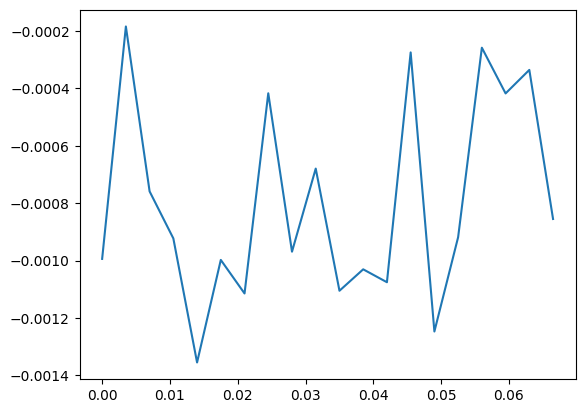

In [ ]:
t = βc-βs
χ = [ t[1]   for (_, _, t, _) in exchanged_replicas]
χ = [np.sum(x)/N for x in χ]
plt.plot(χ, t)

# M = [ t[0]   for (_, _, t, _) in exchanged_replicas]
# M = [np.sum(m)/M for m in M]
# plt.plot(M,t)

In [63]:
βc

np.float64(0.7000000000000001)

In [65]:
βs-βc

array([ 0.    , -0.0035, -0.007 , -0.0105, -0.014 , -0.0175, -0.021 ,
       -0.0245, -0.028 , -0.0315, -0.035 , -0.0385, -0.042 , -0.0455,
       -0.049 , -0.0525, -0.056 , -0.0595, -0.063 , -0.0665])